In [109]:
import pandas as pd
import numpy as np

In [110]:
df=pd.read_csv('../data/raw/AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [111]:
df.columns=df.columns.str.replace(' ', '_').str.lower()

In [112]:
df = df.drop(columns=['order', 'pid'], errors='ignore')
df = df[df['gr_liv_area'] <= 4000] #removed outliner while compared with saleprice and gr_liv_area

In [113]:
df.shape

(2925, 80)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ms_subclass      2925 non-null   int64  
 1   ms_zoning        2925 non-null   object 
 2   lot_frontage     2435 non-null   float64
 3   lot_area         2925 non-null   int64  
 4   street           2925 non-null   object 
 5   alley            198 non-null    object 
 6   lot_shape        2925 non-null   object 
 7   land_contour     2925 non-null   object 
 8   utilities        2925 non-null   object 
 9   lot_config       2925 non-null   object 
 10  land_slope       2925 non-null   object 
 11  neighborhood     2925 non-null   object 
 12  condition_1      2925 non-null   object 
 13  condition_2      2925 non-null   object 
 14  bldg_type        2925 non-null   object 
 15  house_style      2925 non-null   object 
 16  overall_qual     2925 non-null   int64  
 17  overall_cond     29

In [115]:
null_values=df.isnull().sum()
null_values[null_values>0].sort_values(ascending=False)

pool_qc           2914
misc_feature      2820
alley             2727
fence             2354
mas_vnr_type      1774
fireplace_qu      1422
lot_frontage       490
garage_qual        159
garage_cond        159
garage_yr_blt      159
garage_finish      159
garage_type        157
bsmt_exposure       83
bsmtfin_type_2      81
bsmt_cond           80
bsmt_qual           80
bsmtfin_type_1      80
mas_vnr_area        23
bsmt_full_bath       2
bsmt_half_bath       2
bsmtfin_sf_1         1
bsmtfin_sf_2         1
electrical           1
total_bsmt_sf        1
bsmt_unf_sf          1
garage_area          1
garage_cars          1
dtype: int64

In [116]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [117]:
#spliting the data into train and test sets
df.columns

Index(['ms_subclass', 'ms_zoning', 'lot_frontage', 'lot_area', 'street',
       'alley', 'lot_shape', 'land_contour', 'utilities', 'lot_config',
       'land_slope', 'neighborhood', 'condition_1', 'condition_2', 'bldg_type',
       'house_style', 'overall_qual', 'overall_cond', 'year_built',
       'year_remod/add', 'roof_style', 'roof_matl', 'exterior_1st',
       'exterior_2nd', 'mas_vnr_type', 'mas_vnr_area', 'exter_qual',
       'exter_cond', 'foundation', 'bsmt_qual', 'bsmt_cond', 'bsmt_exposure',
       'bsmtfin_type_1', 'bsmtfin_sf_1', 'bsmtfin_type_2', 'bsmtfin_sf_2',
       'bsmt_unf_sf', 'total_bsmt_sf', 'heating', 'heating_qc', 'central_air',
       'electrical', '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf',
       'gr_liv_area', 'bsmt_full_bath', 'bsmt_half_bath', 'full_bath',
       'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'kitchen_qual',
       'totrms_abvgrd', 'functional', 'fireplaces', 'fireplace_qu',
       'garage_type', 'garage_yr_blt', 'garage_finish', 'gara

In [118]:
df.saleprice.describe()

count      2925.000000
mean     180411.574701
std       78554.857286
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      625000.000000
Name: saleprice, dtype: float64

In [119]:
X = df.drop(columns=['saleprice'])
y =df['saleprice']
X['garage_yr_blt'] = X['garage_yr_blt'].replace(2207, 2007)


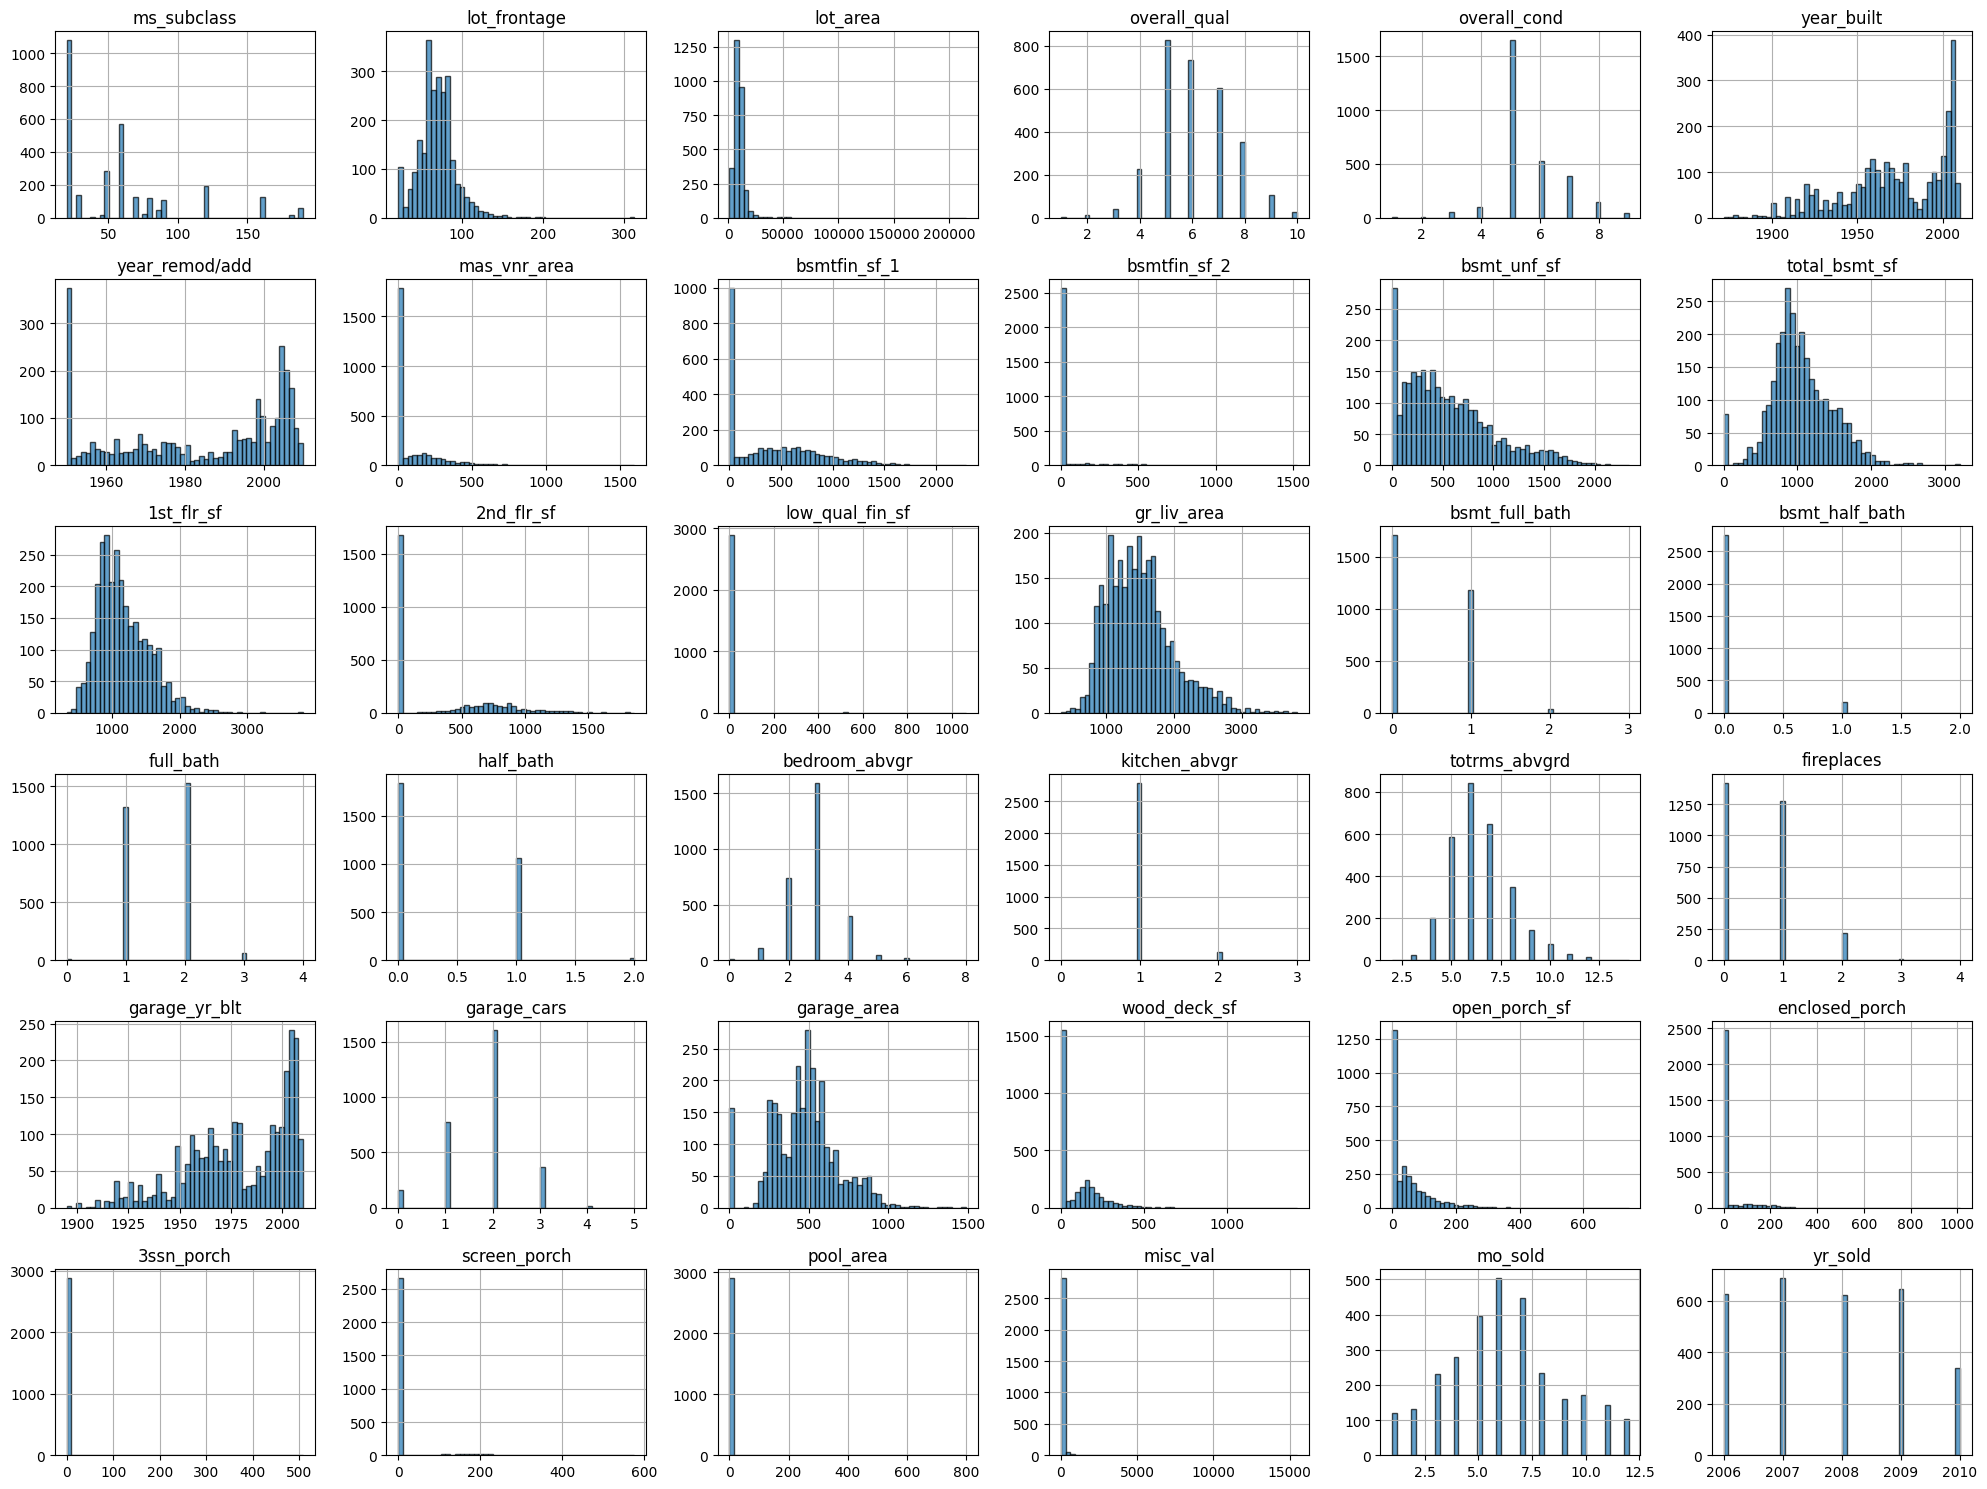

In [120]:
import matplotlib.pyplot as plt

X_numeric_features = X.select_dtypes(include=['int64', 'float64'])

X_numeric_features.hist(bins=50, figsize=(20, 15), edgecolor='black', alpha=0.7)

plt.tight_layout()
plt.show()

In [121]:
df['overall_qual'].value_counts()

overall_qual
5     825
6     732
7     602
8     350
4     226
9     107
3      40
10     26
2      13
1       4
Name: count, dtype: int64

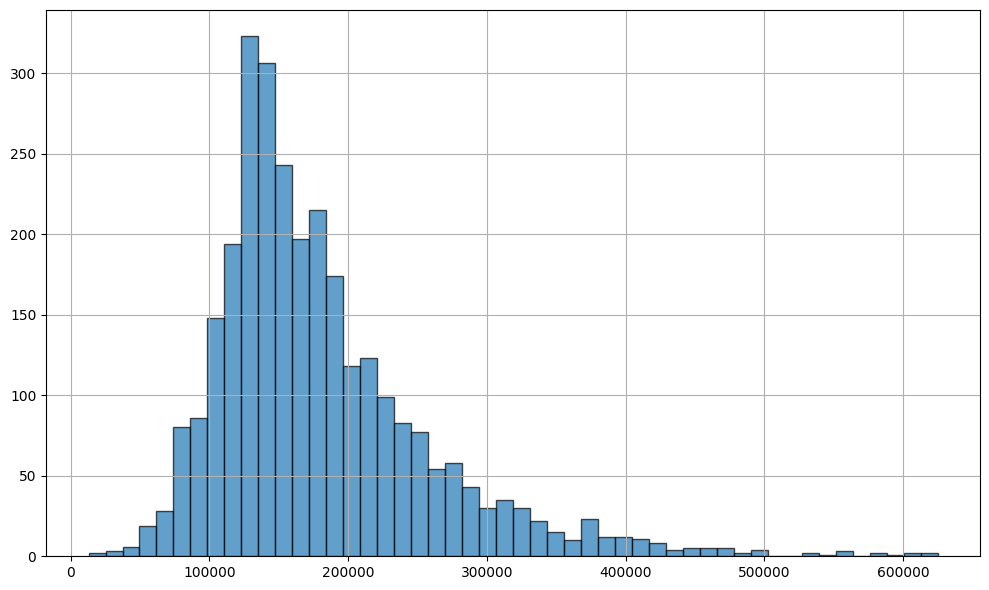

In [122]:
raw_target = df['saleprice']
raw_target.hist(bins=50, figsize=(10, 6), edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

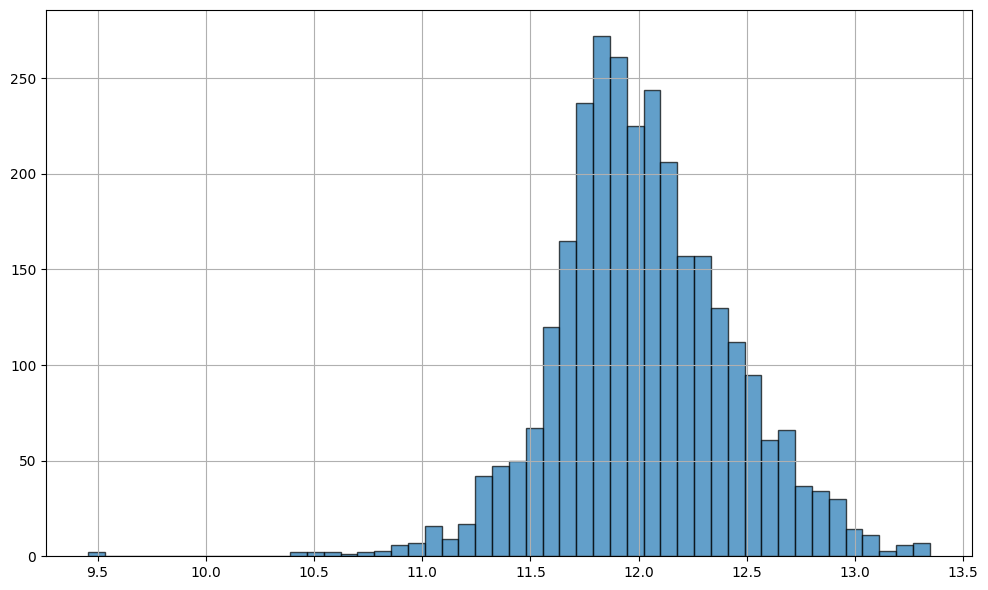

In [123]:
y=np.log1p(df['saleprice'])

y.hist(bins=50, figsize=(10, 6), edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()



In [124]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in splitter.split(df, df['overall_qual']):
    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]
    y_train = y.iloc[train_index]
    y_val = y.iloc[val_index]


In [125]:
train_proportions = X_train['overall_qual'].value_counts(normalize=True).sort_index()
val_proportions = X_val['overall_qual'].value_counts(normalize=True).sort_index()

split_audit_df = pd.DataFrame({
    'Train Set Proportions (%)': train_proportions * 100,
    'Validation Set Proportions (%)': val_proportions * 100
})
print("--- Stratified Split Integrity Check ---")
print(split_audit_df.round(2))


--- Stratified Split Integrity Check ---
              Train Set Proportions (%)  Validation Set Proportions (%)
overall_qual                                                           
1                                  0.13                            0.17
2                                  0.43                            0.51
3                                  1.37                            1.37
4                                  7.74                            7.69
5                                 28.21                           28.21
6                                 25.04                           24.96
7                                 20.60                           20.51
8                                 11.97                           11.97
9                                  3.63                            3.76
10                                 0.90                            0.85


EDA

In [126]:
X=X_train.copy()

In [127]:
X.head()


,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition
1493,60,RL,60.0,6931,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal
2726,20,RL,87.0,13050,Pave,NaN,Reg,Low,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal
1092,60,RL,93.0,10261,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2008,WD,Normal
2834,50,RL,72.0,7822,Pave,NaN,Reg,Bnk,AllPub,Corner,...,0,0,NaN,GdPrv,NaN,0,5,2006,WD,AdjLand
1468,120,RM,37.0,4435,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2008,WD,Normal


In [128]:
X.columns

Index(['ms_subclass', 'ms_zoning', 'lot_frontage', 'lot_area', 'street',
       'alley', 'lot_shape', 'land_contour', 'utilities', 'lot_config',
       'land_slope', 'neighborhood', 'condition_1', 'condition_2', 'bldg_type',
       'house_style', 'overall_qual', 'overall_cond', 'year_built',
       'year_remod/add', 'roof_style', 'roof_matl', 'exterior_1st',
       'exterior_2nd', 'mas_vnr_type', 'mas_vnr_area', 'exter_qual',
       'exter_cond', 'foundation', 'bsmt_qual', 'bsmt_cond', 'bsmt_exposure',
       'bsmtfin_type_1', 'bsmtfin_sf_1', 'bsmtfin_type_2', 'bsmtfin_sf_2',
       'bsmt_unf_sf', 'total_bsmt_sf', 'heating', 'heating_qc', 'central_air',
       'electrical', '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf',
       'gr_liv_area', 'bsmt_full_bath', 'bsmt_half_bath', 'full_bath',
       'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'kitchen_qual',
       'totrms_abvgrd', 'functional', 'fireplaces', 'fireplace_qu',
       'garage_type', 'garage_yr_blt', 'garage_finish', 'gara

In [129]:
import seaborn as sns

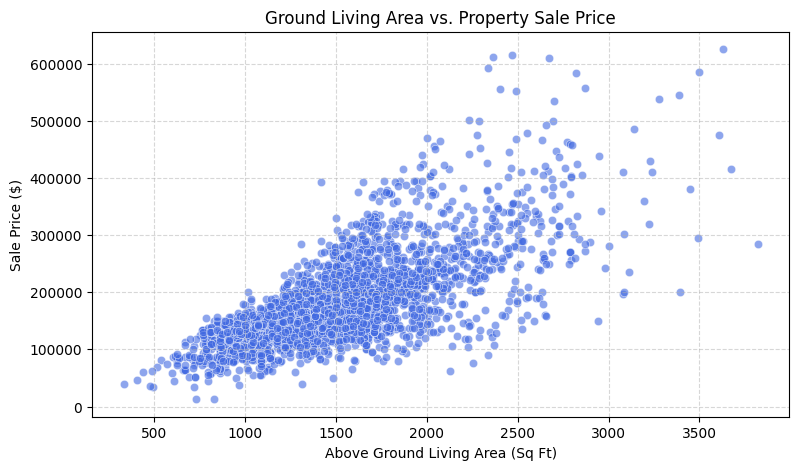

In [130]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='gr_liv_area', y='saleprice', alpha=0.6, color='royalblue')
plt.title("Ground Living Area vs. Property Sale Price")
plt.xlabel("Above Ground Living Area (Sq Ft)")
plt.ylabel("Sale Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.show()

C:\Users\ABHIJITH\AppData\Local\Temp\ipykernel_9500\4180891938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='overall_qual', y='saleprice', palette='viridis')


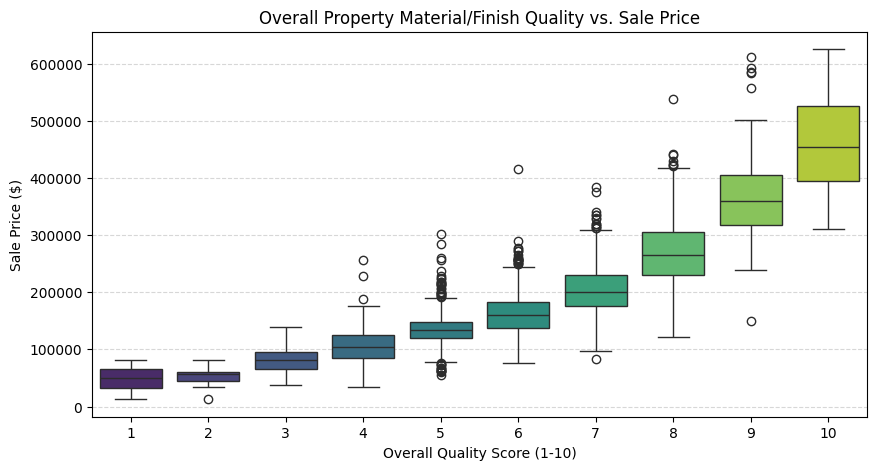

In [131]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='overall_qual', y='saleprice', palette='viridis')
plt.title("Overall Property Material/Finish Quality vs. Sale Price")
plt.xlabel("Overall Quality Score (1-10)")
plt.ylabel("Sale Price ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Correlations

In [132]:
train_numeric_features = X_train.select_dtypes(include=['int64', 'float64']).copy()
train_numeric_features['saleprice'] = y_train

corr_matrix = train_numeric_features.corr()

print("--- CORRELATION WITH SALEPRICE ---")
corr_matrix['saleprice'].sort_values(ascending=False)

--- CORRELATION WITH SALEPRICE ---


saleprice          1.000000
overall_qual       0.825417
gr_liv_area        0.703130
garage_cars        0.666434
garage_area        0.650201
total_bsmt_sf      0.634812
year_built         0.608109
1st_flr_sf         0.606042
year_remod/add     0.583234
garage_yr_blt      0.582731
full_bath          0.576664
totrms_abvgrd      0.492969
fireplaces         0.484457
mas_vnr_area       0.434438
bsmtfin_sf_1       0.416313
lot_frontage       0.365013
wood_deck_sf       0.327210
open_porch_sf      0.317301
half_bath          0.296999
2nd_flr_sf         0.270877
bsmt_full_bath     0.269744
lot_area           0.247108
bsmt_unf_sf        0.190459
bedroom_abvgr      0.177306
screen_porch       0.098278
3ssn_porch         0.040677
pool_area          0.039897
mo_sold            0.023509
bsmtfin_sf_2       0.015255
misc_val          -0.007508
bsmt_half_bath    -0.022752
yr_sold           -0.030936
low_qual_fin_sf   -0.032694
overall_cond      -0.036781
ms_subclass       -0.067378
kitchen_abvgr     -0

In [133]:
X_numeric_features=train_numeric_features

In [134]:

X_train = X_train.copy()
X_val = X_val.copy()

In [135]:
X_train['total_sq_ft'] = X_train['1st_flr_sf'] + X_train['2nd_flr_sf'] + X_train['total_bsmt_sf']
X_val['total_sq_ft'] = X_val['1st_flr_sf'] + X_val['2nd_flr_sf'] + X_val['total_bsmt_sf']

X_train['total_bathrooms'] = X_train['full_bath'] + (X_train['half_bath'] * 0.5) + X_train['bsmt_full_bath'] + (X_train['bsmt_half_bath'] * 0.5)
X_val['total_bathrooms'] = X_val['full_bath'] + (X_val['half_bath'] * 0.5) + X_val['bsmt_full_bath'] + (X_val['bsmt_half_bath'] * 0.5)

X_train['property_age'] = X_train['yr_sold'] - X_train['year_built']
X_val['property_age'] = X_val['yr_sold'] - X_val['year_built']


redundant_cols = [
    '1st_flr_sf', '2nd_flr_sf', 'total_bsmt_sf',
    'full_bath', 'half_bath', 'bsmt_full_bath', 'bsmt_half_bath',
    'year_built', 'garage_area', 'garage_yr_blt'
]

X_train = X_train.drop(columns=redundant_cols, errors='ignore')
X_val = X_val.drop(columns=redundant_cols, errors='ignore')

In [136]:
X_train.shape, X_val.shape

((2340, 72), (585, 72))

In [137]:
train_numeric_features = X_train.select_dtypes(include=['int64', 'float64']).copy()
train_numeric_features['saleprice'] = y_train

corr_matrix = train_numeric_features.corr()

print("--- CORRELATION WITH SALEPRICE ---")
corr_matrix['saleprice'].sort_values(ascending=False).iloc[1:11]

--- CORRELATION WITH SALEPRICE ---


overall_qual       0.825417
total_sq_ft        0.808649
gr_liv_area        0.703130
garage_cars        0.666434
total_bathrooms    0.661494
year_remod/add     0.583234
totrms_abvgrd      0.492969
fireplaces         0.484457
mas_vnr_area       0.434438
bsmtfin_sf_1       0.416313
Name: saleprice, dtype: float64

In [138]:
X_train.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,total_sq_ft,total_bathrooms,property_age
1493,60,RL,60.0,6931,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,7,2008,WD,Normal,2402.0,2.5,5
2726,20,RL,87.0,13050,Pave,NaN,Reg,Low,AllPub,Inside,...,NaN,NaN,0,4,2006,WD,Normal,2000.0,2.0,43
1092,60,RL,93.0,10261,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,0,5,2008,WD,Normal,2728.0,3.5,8
2834,50,RL,72.0,7822,Pave,NaN,Reg,Bnk,AllPub,Corner,...,GdPrv,NaN,0,5,2006,WD,AdjLand,2170.0,2.0,91
1468,120,RM,37.0,4435,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,0,3,2008,WD,Normal,1696.0,2.0,5


In [139]:
y_train = y_train.to_frame()

In [140]:
y_train.head()

,saleprice
1493,12.016128
2726,12.007628
1092,12.136192
2834,11.429555
1468,11.824087


In [141]:

##import os

##os.makedirs('../data/processed', exist_ok=True)


##X_train.to_csv('../data/processed/X_train.csv', index=True)
##X_val.to_csv('../data/processed/X_val.csv', index=True)
##y_train.to_csv('../data/processed/y_train.csv', index=True)
##y_val.to_csv('../data/processed/y_val.csv', index=True)


##print("Clean data partitions exported successfully!")


In [142]:
train_numeric_features.columns

Index(['ms_subclass', 'lot_frontage', 'lot_area', 'overall_qual',
       'overall_cond', 'year_remod/add', 'mas_vnr_area', 'bsmtfin_sf_1',
       'bsmtfin_sf_2', 'bsmt_unf_sf', 'low_qual_fin_sf', 'gr_liv_area',
       'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'fireplaces',
       'garage_cars', 'wood_deck_sf', 'open_porch_sf', 'enclosed_porch',
       '3ssn_porch', 'screen_porch', 'pool_area', 'misc_val', 'mo_sold',
       'yr_sold', 'total_sq_ft', 'total_bathrooms', 'property_age',
       'saleprice'],
      dtype='object')

In [143]:
single_house_1 = {
    "overall_qual": 6,
    "bsmt_qual": "TA",
    "exter_qual": "TA",
    "1st_flr_sf": 1656,
    "2nd_flr_sf": 0,
    "total_bsmt_sf": 1080,
    "central_air": "Y",
    "garage_cars": 2,
    "garage_cond": "TA",
    "ms_zoning": "RL",
    "kitchen_qual": "TA",
    "full_bath": 1,
    "half_bath": 0,
    "bsmt_full_bath": 1,
    "bsmt_half_bath": 0,
    "fireplaces": 2,
    "paved_drive": "P",
    "roof_style": "Hip",
    "year_remod/add": 1960,
    "gr_liv_area": 1656,
    "yr_sold": 2010,
    "year_built": 1960,
    "functional": "Typ",
    "fireplace_qu": "Gd",
    "neighborhood": "NAmes",
    "sale_condition": "Normal",
    "overall_cond": 5,
    "exter_cond": "TA"
}
user_numeric_features = [
    key for key, value in single_house_1.items() 
    if isinstance(value, (int, float)) and not isinstance(value, bool)
]

print(user_numeric_features)


['overall_qual', '1st_flr_sf', '2nd_flr_sf', 'total_bsmt_sf', 'garage_cars', 'full_bath', 'half_bath', 'bsmt_full_bath', 'bsmt_half_bath', 'fireplaces', 'year_remod/add', 'gr_liv_area', 'yr_sold', 'year_built', 'overall_cond']


In [144]:
corr_matrix=X_numeric_features.corr(numeric_only=True)


In [145]:
corr_matrix.gr_liv_area.sort_values(ascending=False)

gr_liv_area        1.000000
totrms_abvgrd      0.809624
saleprice          0.703130
2nd_flr_sf         0.666491
full_bath          0.637497
overall_qual       0.562693
bedroom_abvgr      0.543808
1st_flr_sf         0.522570
garage_cars        0.488352
garage_area        0.477182
fireplaces         0.446012
half_bath          0.429309
total_bsmt_sf      0.386553
mas_vnr_area       0.371299
lot_frontage       0.349703
open_porch_sf      0.320563
year_remod/add     0.304544
garage_yr_blt      0.266324
lot_area           0.257336
bsmt_unf_sf        0.241095
wood_deck_sf       0.239973
year_built         0.225398
bsmtfin_sf_1       0.141158
kitchen_abvgr      0.121232
low_qual_fin_sf    0.118266
pool_area          0.091336
screen_porch       0.081800
ms_subclass        0.079428
bsmt_full_bath     0.042816
mo_sold            0.041295
enclosed_porch     0.004387
3ssn_porch         0.001782
yr_sold           -0.018244
misc_val          -0.019311
bsmtfin_sf_2      -0.028974
bsmt_half_bath    -0

In [146]:
corr_matrix.columns

Index(['ms_subclass', 'lot_frontage', 'lot_area', 'overall_qual',
       'overall_cond', 'year_built', 'year_remod/add', 'mas_vnr_area',
       'bsmtfin_sf_1', 'bsmtfin_sf_2', 'bsmt_unf_sf', 'total_bsmt_sf',
       '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf', 'gr_liv_area',
       'bsmt_full_bath', 'bsmt_half_bath', 'full_bath', 'half_bath',
       'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'fireplaces',
       'garage_yr_blt', 'garage_cars', 'garage_area', 'wood_deck_sf',
       'open_porch_sf', 'enclosed_porch', '3ssn_porch', 'screen_porch',
       'pool_area', 'misc_val', 'mo_sold', 'yr_sold', 'saleprice'],
      dtype='object')

In [ ]:
high_corr_targets = []

valid_user_features = [feat for feat in user_numeric_features if feat in corr_matrix.index]

for col in corr_matrix.columns:
    if col not in user_numeric_features:
        if valid_user_features:
            abs_corr_series = corr_matrix[col].loc[valid_user_features].abs()
            max_corr = abs_corr_series.max()
            best_matching_column = abs_corr_series.idxmax()
            
            if max_corr >= 0.50:
                high_corr_targets.append(col)
                print(f"Feature '{col}' is highly correlated with '{best_matching_column}' (R = {max_corr:.2f})")

print(f"\nFinal list of columns for KNNImputer: {high_corr_targets}")


Feature 'bsmtfin_sf_1' is highly correlated with 'bsmt_full_bath' (R = 0.65)
Feature 'bedroom_abvgr' is highly correlated with 'gr_liv_area' (R = 0.54)
Feature 'totrms_abvgrd' is highly correlated with 'gr_liv_area' (R = 0.81)
Feature 'garage_yr_blt' is highly correlated with 'year_built' (R = 0.84)
Feature 'garage_area' is highly correlated with 'garage_cars' (R = 0.89)
Feature 'saleprice' is highly correlated with 'overall_qual' (R = 0.83)

Final list of columns for KNNImputer: ['bsmtfin_sf_1', 'bedroom_abvgr', 'totrms_abvgrd', 'garage_yr_blt', 'garage_area', 'saleprice']
